# 02 Interpret Results

Load a completed sweep and regenerate figures + robust summaries + paper claims.


In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)

src_path = str(PROJECT_ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print("Project root:", PROJECT_ROOT)


Project root: /Users/adityadutta/Desktop/GitHub/ess-ope-diagnostics


In [2]:
import pandas as pd

from ess_ope.evaluation.summary import (
    PaperClaimConfig,
    SummaryConfig,
    build_condition_summary,
    build_estimator_summary,
    build_paper_claim_summary,
    build_paper_claims_table,
)
from ess_ope.plotting.benchmark_figures import generate_benchmark_figures

latest_dir = (PROJECT_ROOT / "results/latest").resolve()
pq = latest_dir / "sweep_results.parquet"
csv = latest_dir / "sweep_results.csv"

if pq.exists():
    df = pd.read_parquet(pq)
    source = pq
elif csv.exists():
    df = pd.read_csv(csv)
    source = csv
else:
    raise FileNotFoundError("No sweep_results in results/latest")

print("Loaded:", source)
print("Rows:", len(df))
print("alphas:", sorted(df.alpha.unique().tolist()))
print("betas:", sorted(df.beta.unique().tolist()))
print("K:", sorted(df.K.unique().tolist()))
if "env_repeat_id" in df:
    print("env_repeats:", sorted(df.env_repeat_id.unique().tolist()))
if "policy_repeat_id" in df:
    print("policy_repeats:", sorted(df.policy_repeat_id.unique().tolist()))
if "repeat_id" in df:
    print("dataset_repeats:", sorted(df.repeat_id.unique().tolist()))


Loaded: /Users/adityadutta/Desktop/GitHub/ess-ope-diagnostics/results/20260225_032705_benchmark_smoke/sweep_results.parquet
Rows: 270
alphas: [0.0, 0.25, 0.5, 0.75, 1.0]
betas: [0.0, 0.5, 1.0]
K: [100, 500]
env_repeats: [0]
policy_repeats: [0]
dataset_repeats: [0, 1, 2]


In [3]:
fig_dir = latest_dir / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

benchmark_report = generate_benchmark_figures(df, output_dir=fig_dir, fixed_alpha=None, fixed_beta=0.0)
summary_cfg = SummaryConfig(bootstrap_samples=600, bootstrap_max_points=8000)
estimator_summary = build_estimator_summary(df, config=summary_cfg)
condition_summary = build_condition_summary(df)
paper_claims = build_paper_claims_table(df, estimator_summary, benchmark_report, config=PaperClaimConfig())
paper_claim_summary = build_paper_claim_summary(paper_claims)

benchmark_report.to_csv(fig_dir / "benchmark_report.csv", index=False)
estimator_summary.to_csv(fig_dir / "estimator_summary.csv", index=False)
condition_summary.to_csv(fig_dir / "condition_summary.csv", index=False)
paper_claims.to_csv(fig_dir / "paper_claims.csv", index=False)
paper_claim_summary.to_csv(fig_dir / "paper_claim_summary.csv", index=False)

print("Saved to:", fig_dir)
paper_claims


Saved to: /Users/adityadutta/Desktop/GitHub/ess-ope-diagnostics/results/20260225_032705_benchmark_smoke/figures


,claim_id,estimator,statement,metric,value,ci_low,ci_high,threshold,verdict,confidence,aux_metric_ess_cv,aux_metric_alpha_fixed,aux_metric_ess_ratio,aux_metric_beta_fixed
0,C1_IS_ESS_INFORMATIVE,IS-PDIS,ESS should negatively correlate with IS error.,"spearman(ESS_norm, abs_error)",-0.477210,-0.573507,-0.362147,ci_high < 0 (strong: < -0.2),supported,medium,NaN,NaN,NaN,NaN
1,C2_FQE_WEAK_ESS_CORR,FQE,ESS should be weak/non-diagnostic for non-IS e...,"spearman(ESS_norm, abs_error)",-0.001780,-0.115296,0.115451,|corr| <= 0.15 (primary effect-size threshold)...,supported,medium,NaN,NaN,NaN,NaN
2,C3_DM_SAME_ESS_DIFF_ERROR,DM,"At fixed alpha (similar ESS), error can differ...",error_range_over_beta / mean_abs_error,0.817464,NaN,NaN,ESS_CV <= 0.12 and rel_error_range >= 0.4 (str...,supported,medium,0.091323,0.5,NaN,NaN
3,C3_FQE_SAME_ESS_DIFF_ERROR,FQE,"At fixed alpha (similar ESS), error can differ...",error_range_over_beta / mean_abs_error,0.977327,NaN,NaN,ESS_CV <= 0.12 and rel_error_range >= 0.4 (str...,supported,medium,0.091323,0.5,NaN,NaN
4,C4_DM_ESS_SHIFT_ERROR_STABLE,DM,"Across alpha at fixed beta, ESS may vary stron...",error_range_over_alpha / mean_abs_error,0.138107,NaN,NaN,ESS_ratio >= 3.0 and rel_error_range <= 0.35 (...,supported,medium,NaN,NaN,159.939016,0.0
5,C4_FQE_ESS_SHIFT_ERROR_STABLE,FQE,"Across alpha at fixed beta, ESS may vary stron...",error_range_over_alpha / mean_abs_error,0.001178,NaN,NaN,ESS_ratio >= 3.0 and rel_error_range <= 0.35 (...,supported,medium,NaN,NaN,159.939016,0.0
6,C2_DM_WEAK_ESS_CORR,DM,ESS should be weak/non-diagnostic for non-IS e...,"spearman(ESS_norm, abs_error)",-0.089889,-0.200611,0.034716,|corr| <= 0.15 (primary effect-size threshold)...,partially_supported,medium,NaN,NaN,NaN,NaN
7,C3_MRDR_SAME_ESS_DIFF_ERROR,MRDR,"At fixed alpha (similar ESS), error can differ...",error_range_over_beta / mean_abs_error,0.610429,NaN,NaN,ESS_CV <= 0.12 and rel_error_range >= 0.4 (str...,partially_supported,medium,0.091323,0.5,NaN,NaN
8,C4_MRDR_ESS_SHIFT_ERROR_STABLE,MRDR,"Across alpha at fixed beta, ESS may vary stron...",error_range_over_alpha / mean_abs_error,0.348160,NaN,NaN,ESS_ratio >= 3.0 and rel_error_range <= 0.35 (...,partially_supported,medium,NaN,NaN,159.939016,0.0
9,C2_MRDR_WEAK_ESS_CORR,MRDR,ESS should be weak/non-diagnostic for non-IS e...,"spearman(ESS_norm, abs_error)",-0.415535,-0.509403,-0.314989,|corr| <= 0.15 (primary effect-size threshold)...,not_supported,medium,NaN,NaN,NaN,NaN


In [4]:
paper_claim_summary


,verdict,count,fraction
0,supported,6,0.6
1,partially_supported,3,0.3
2,not_supported,1,0.1


benchmark_fig1_ess_vs_error_by_estimator.png


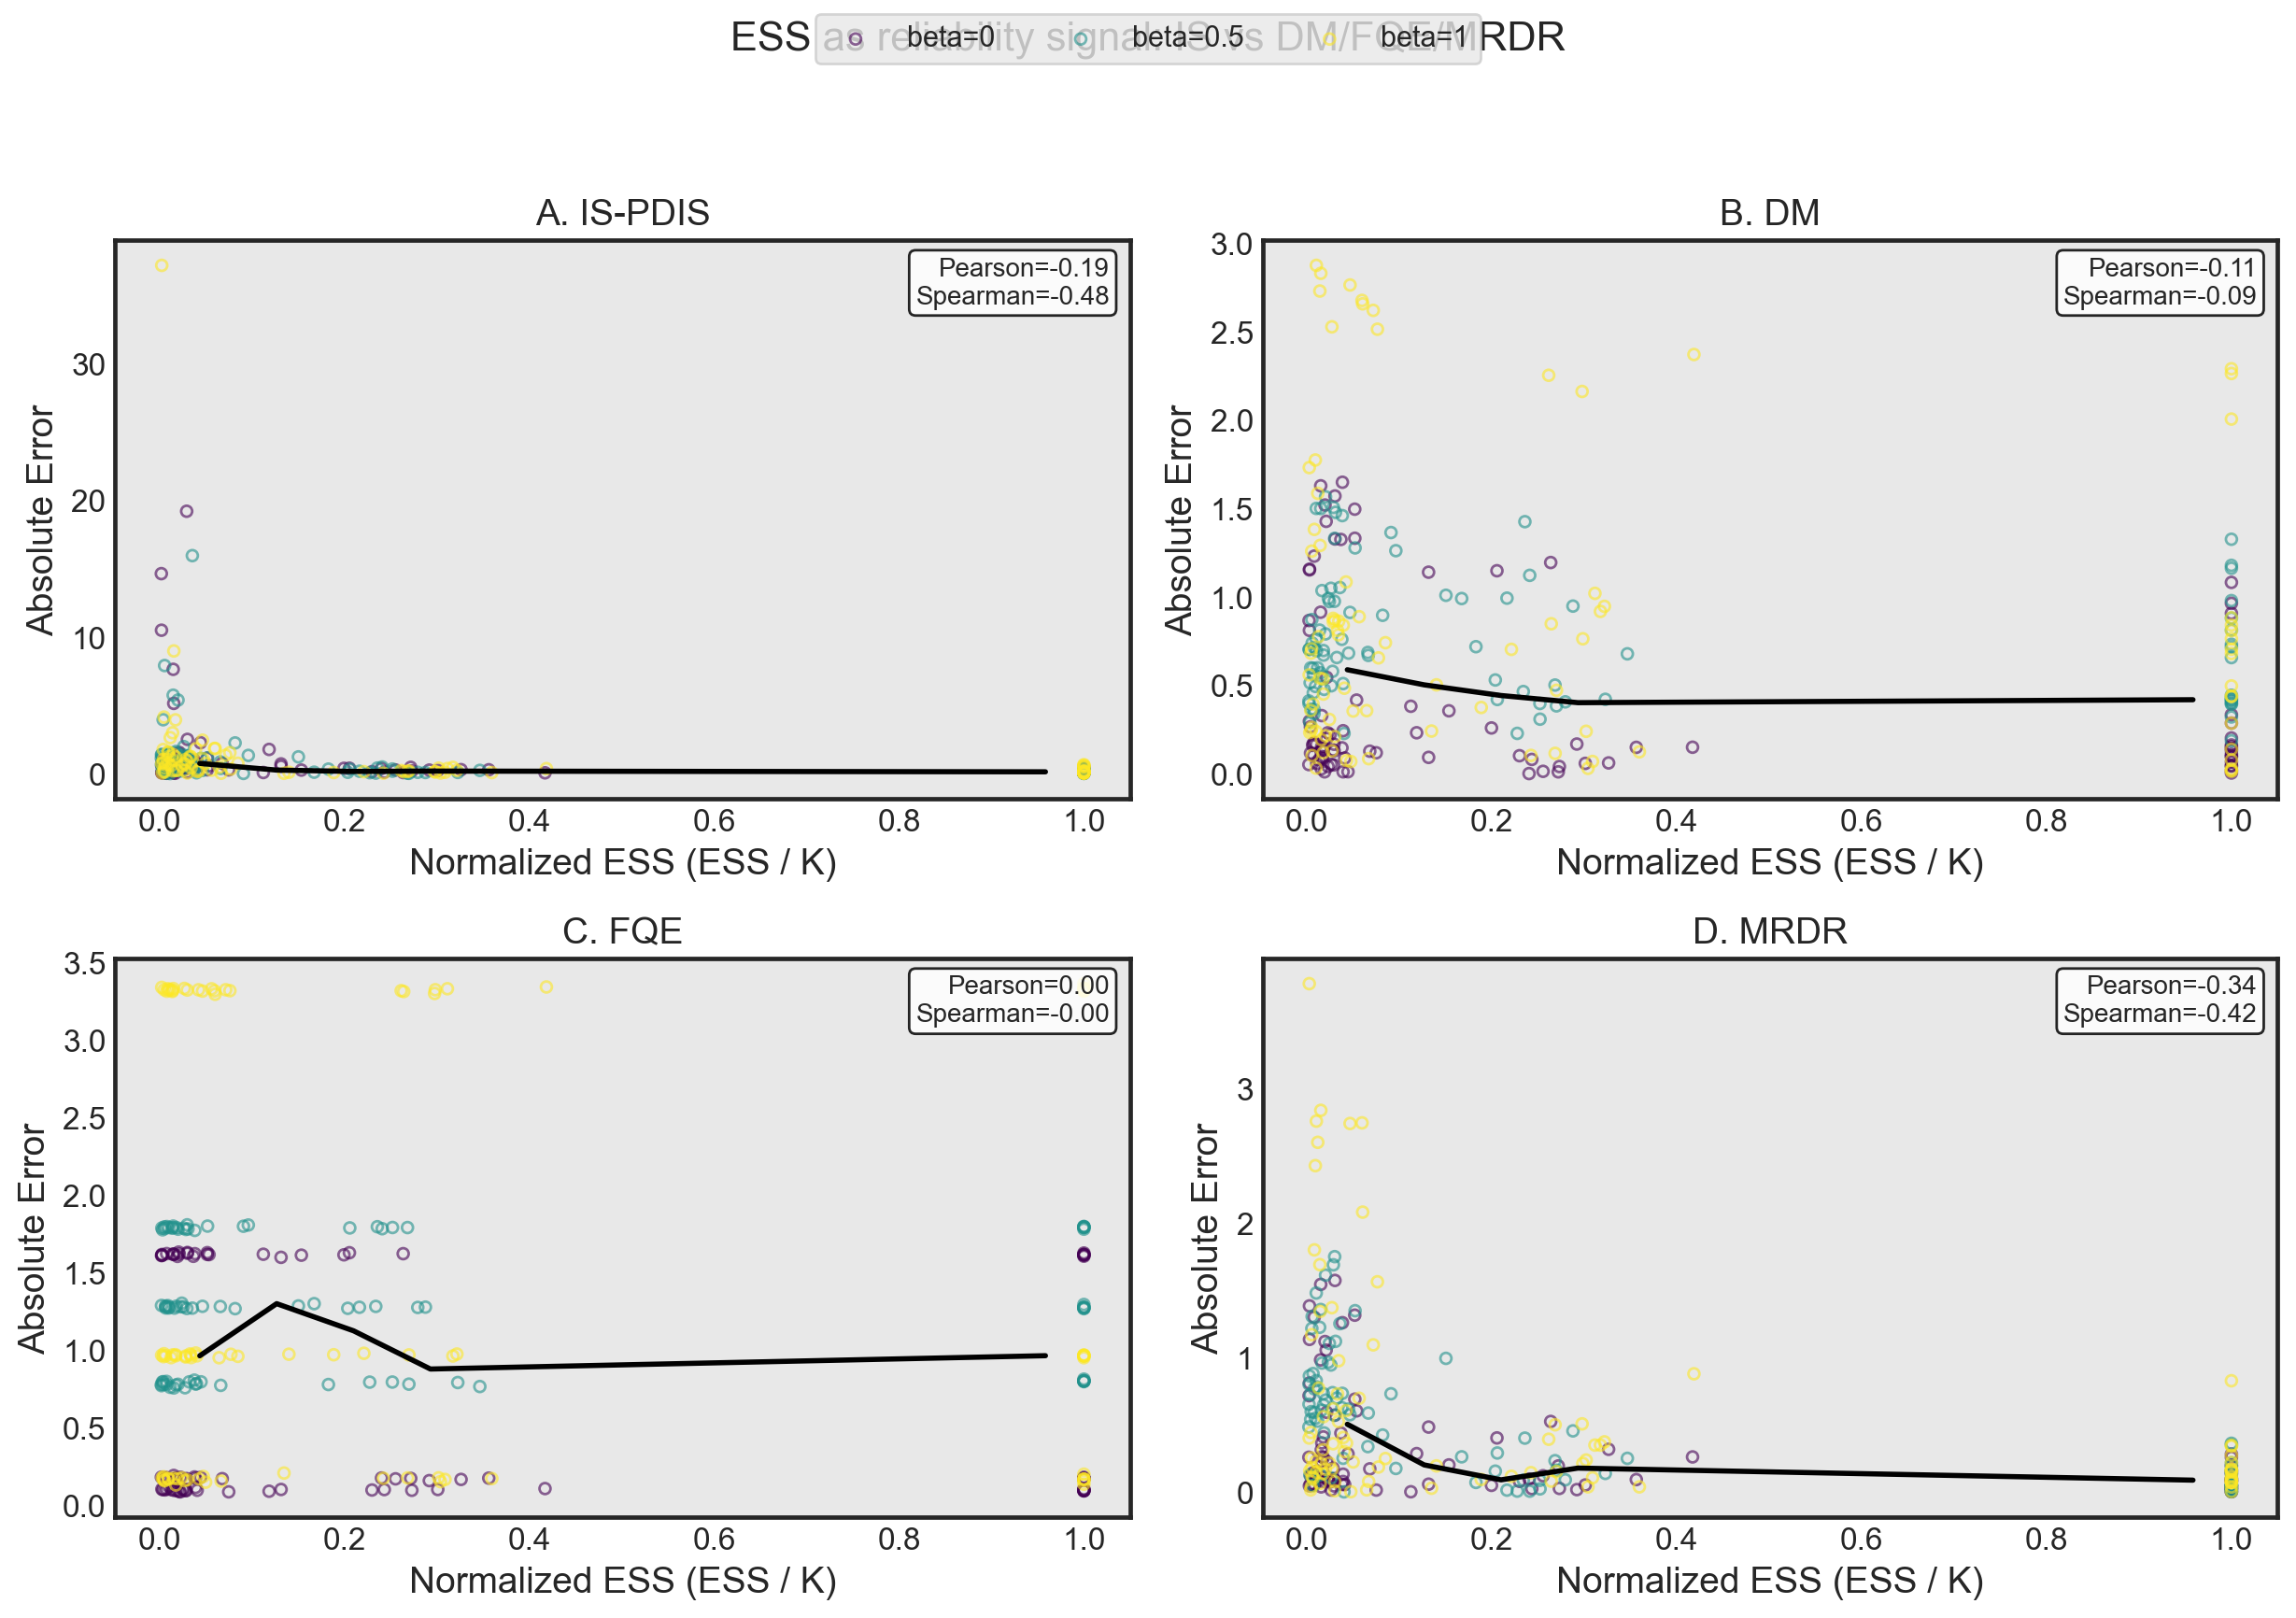

benchmark_fig2_same_ess_different_error.png


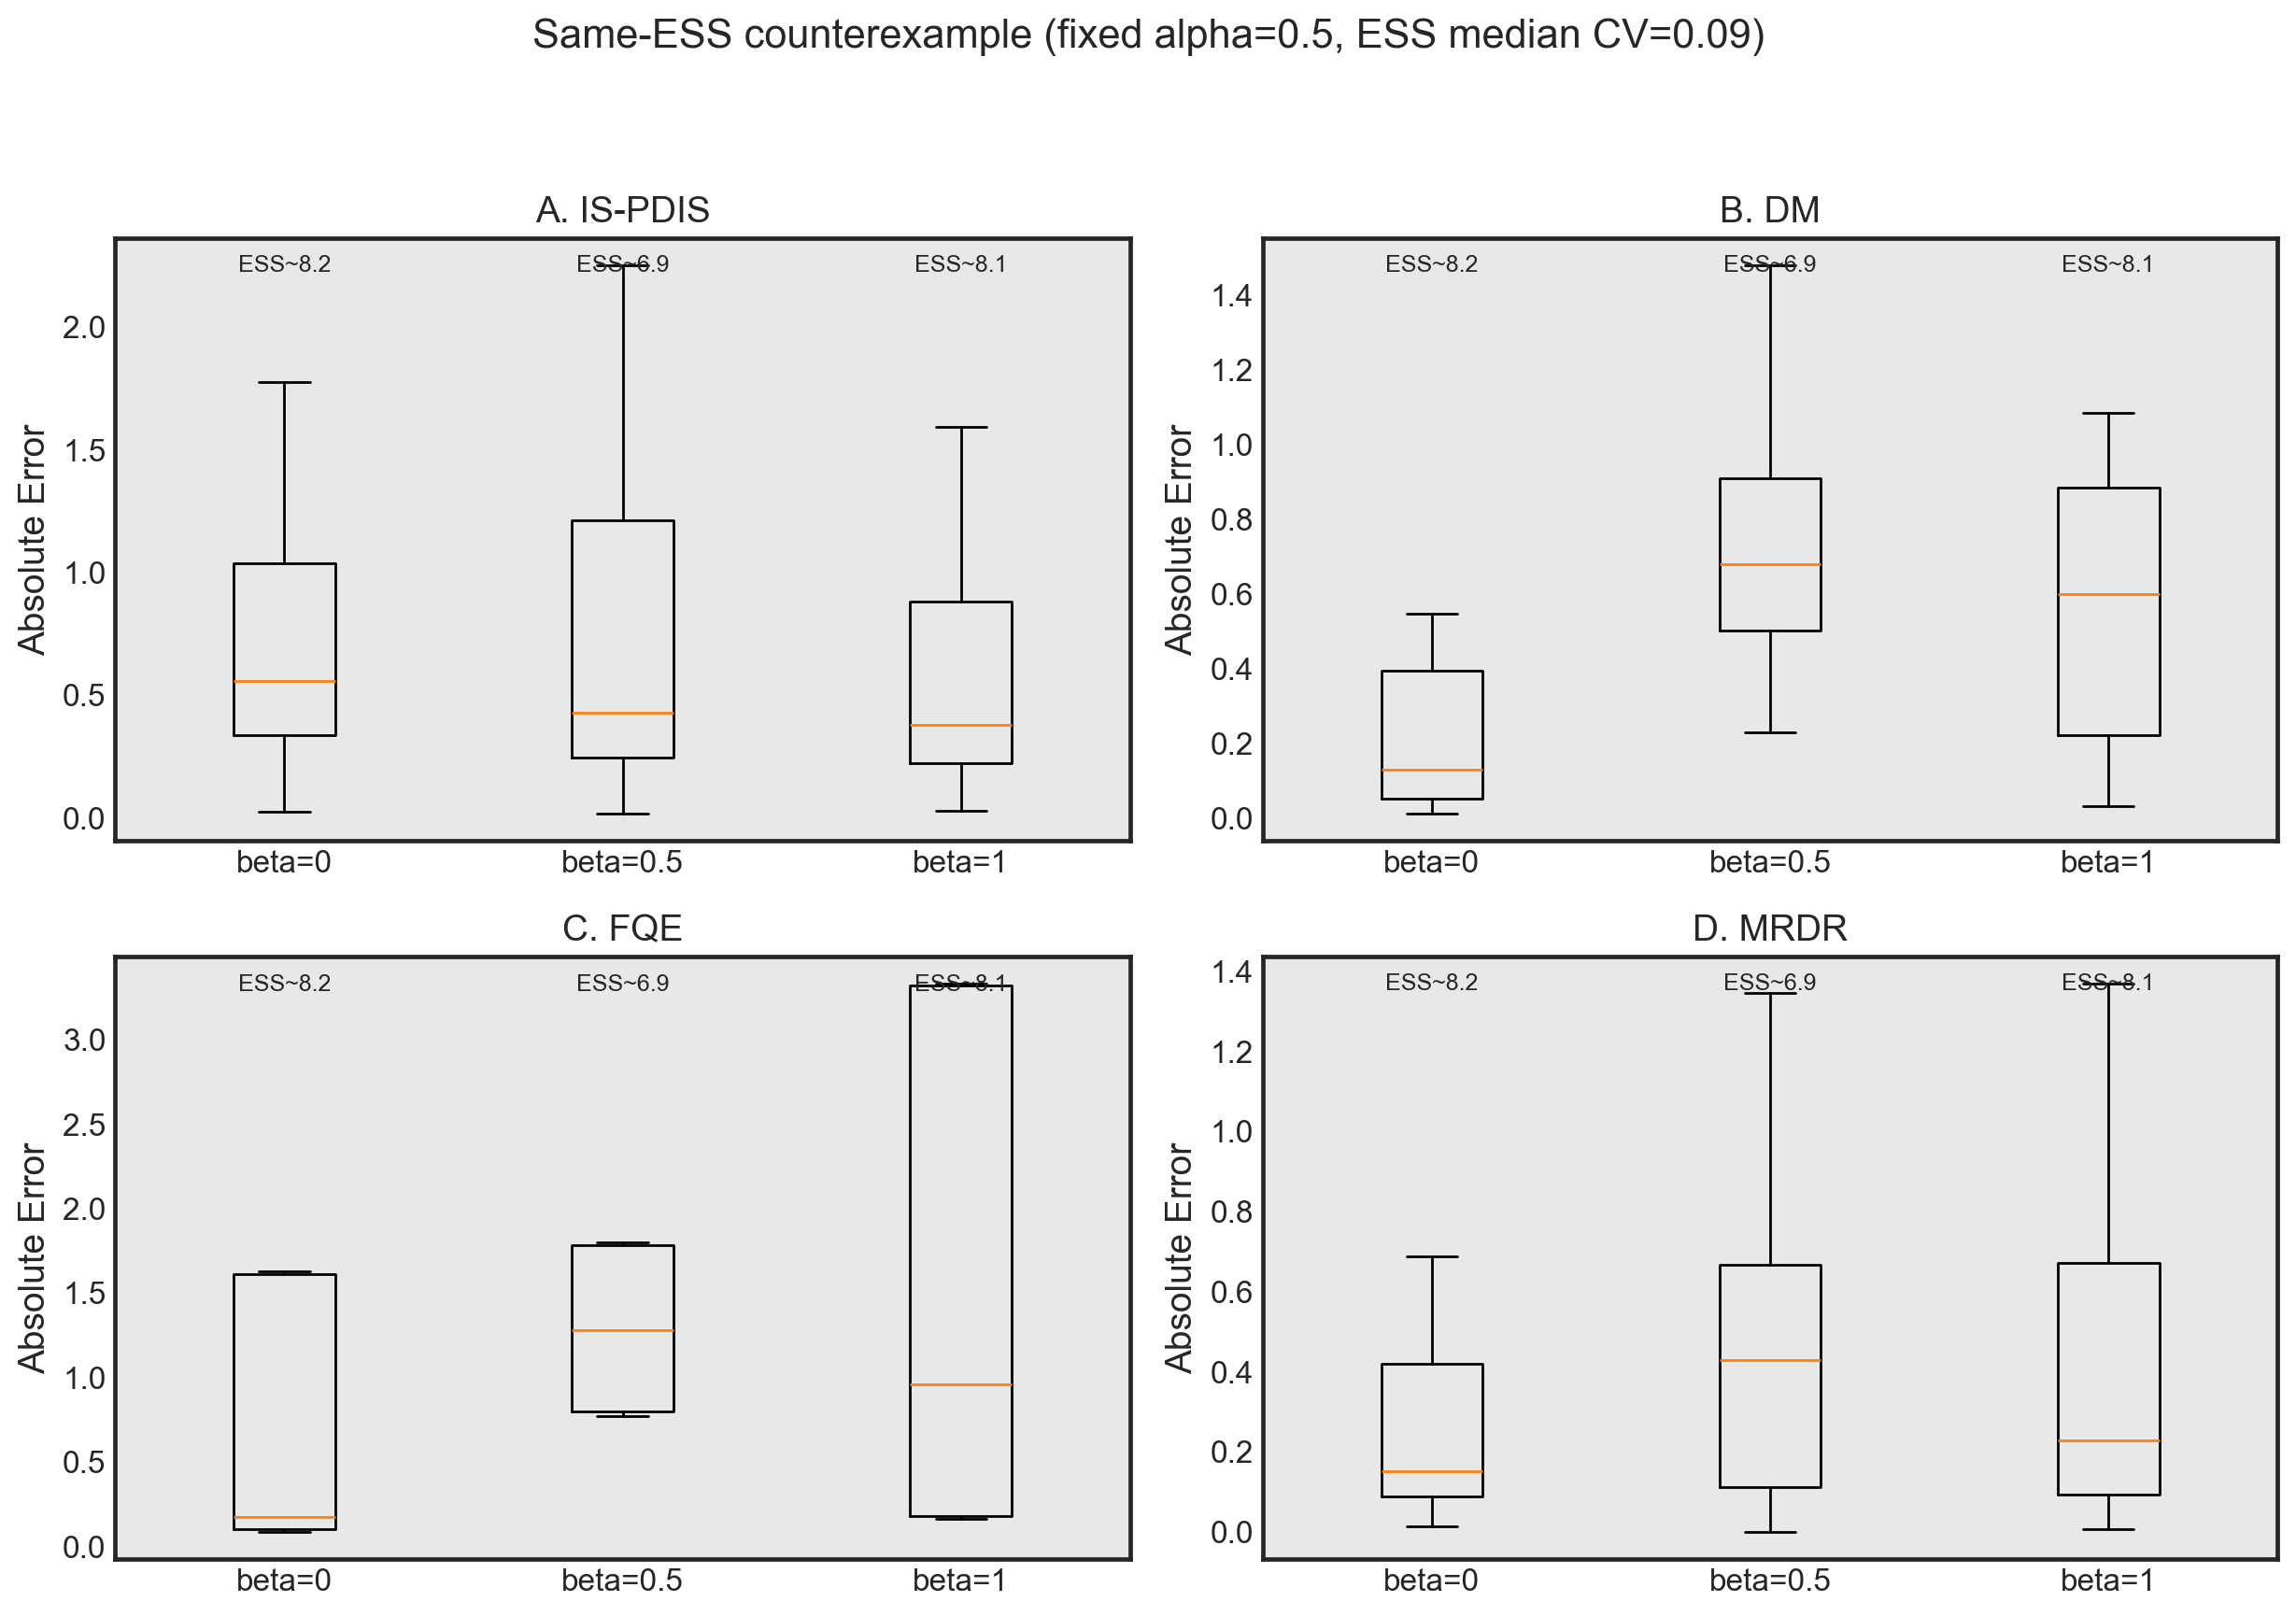

benchmark_fig3_ess_changes_error_stability.png


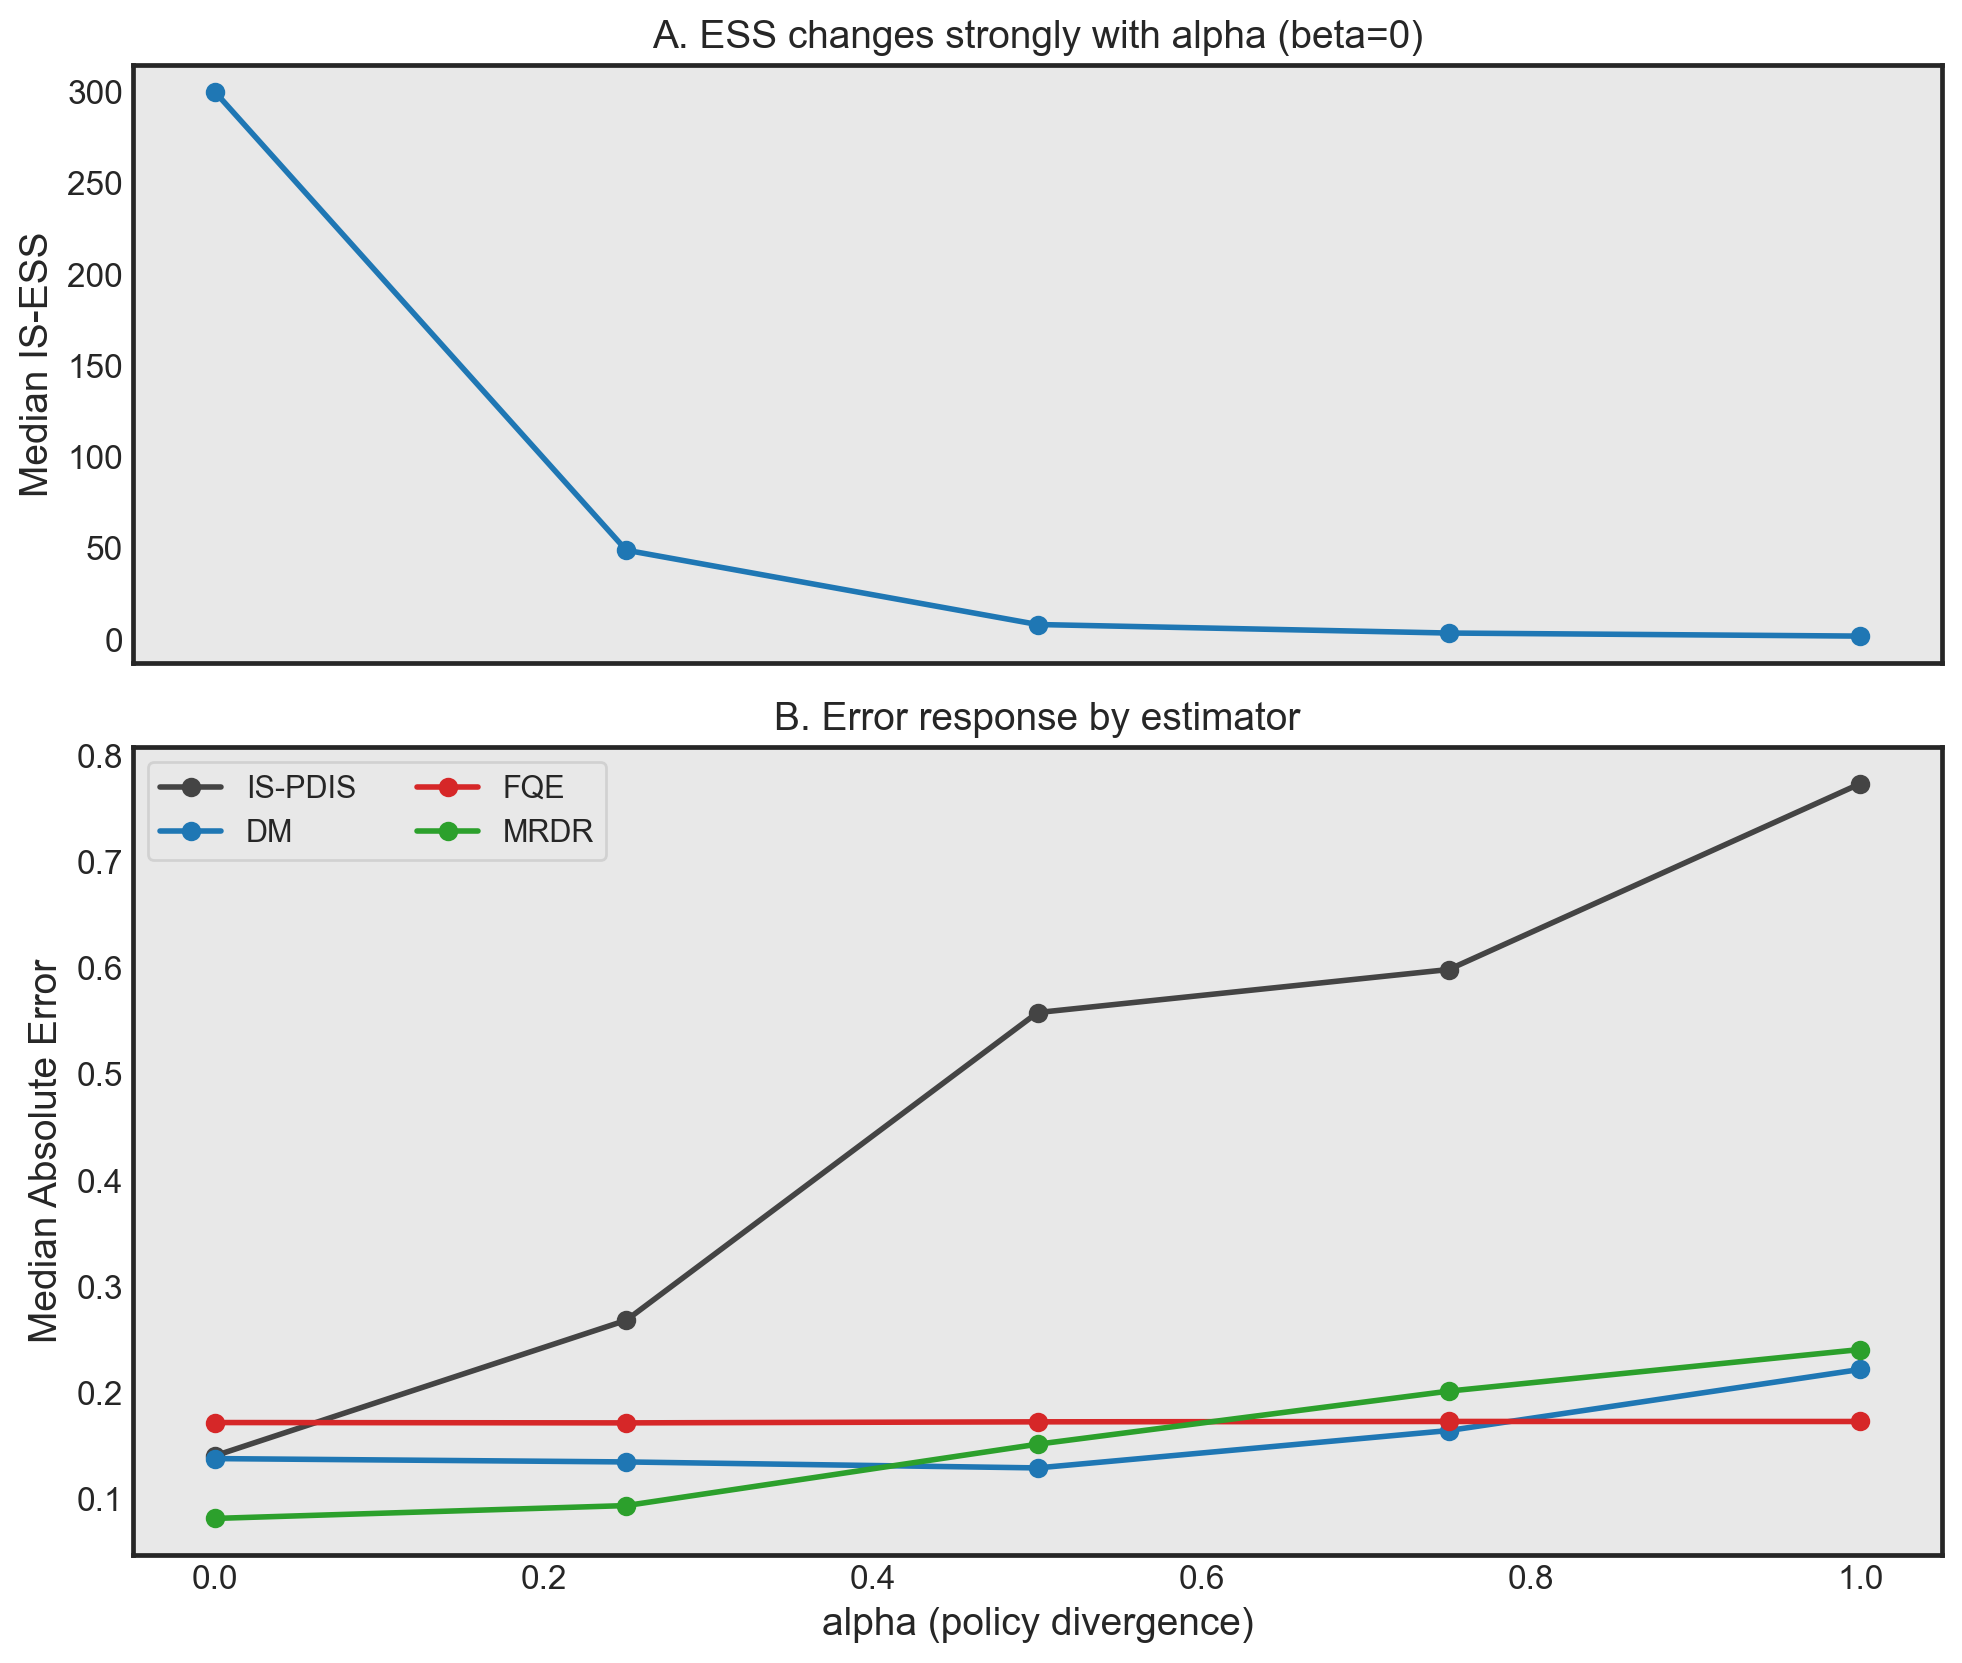

benchmark_fig4_fan_estimate_vs_ess.png


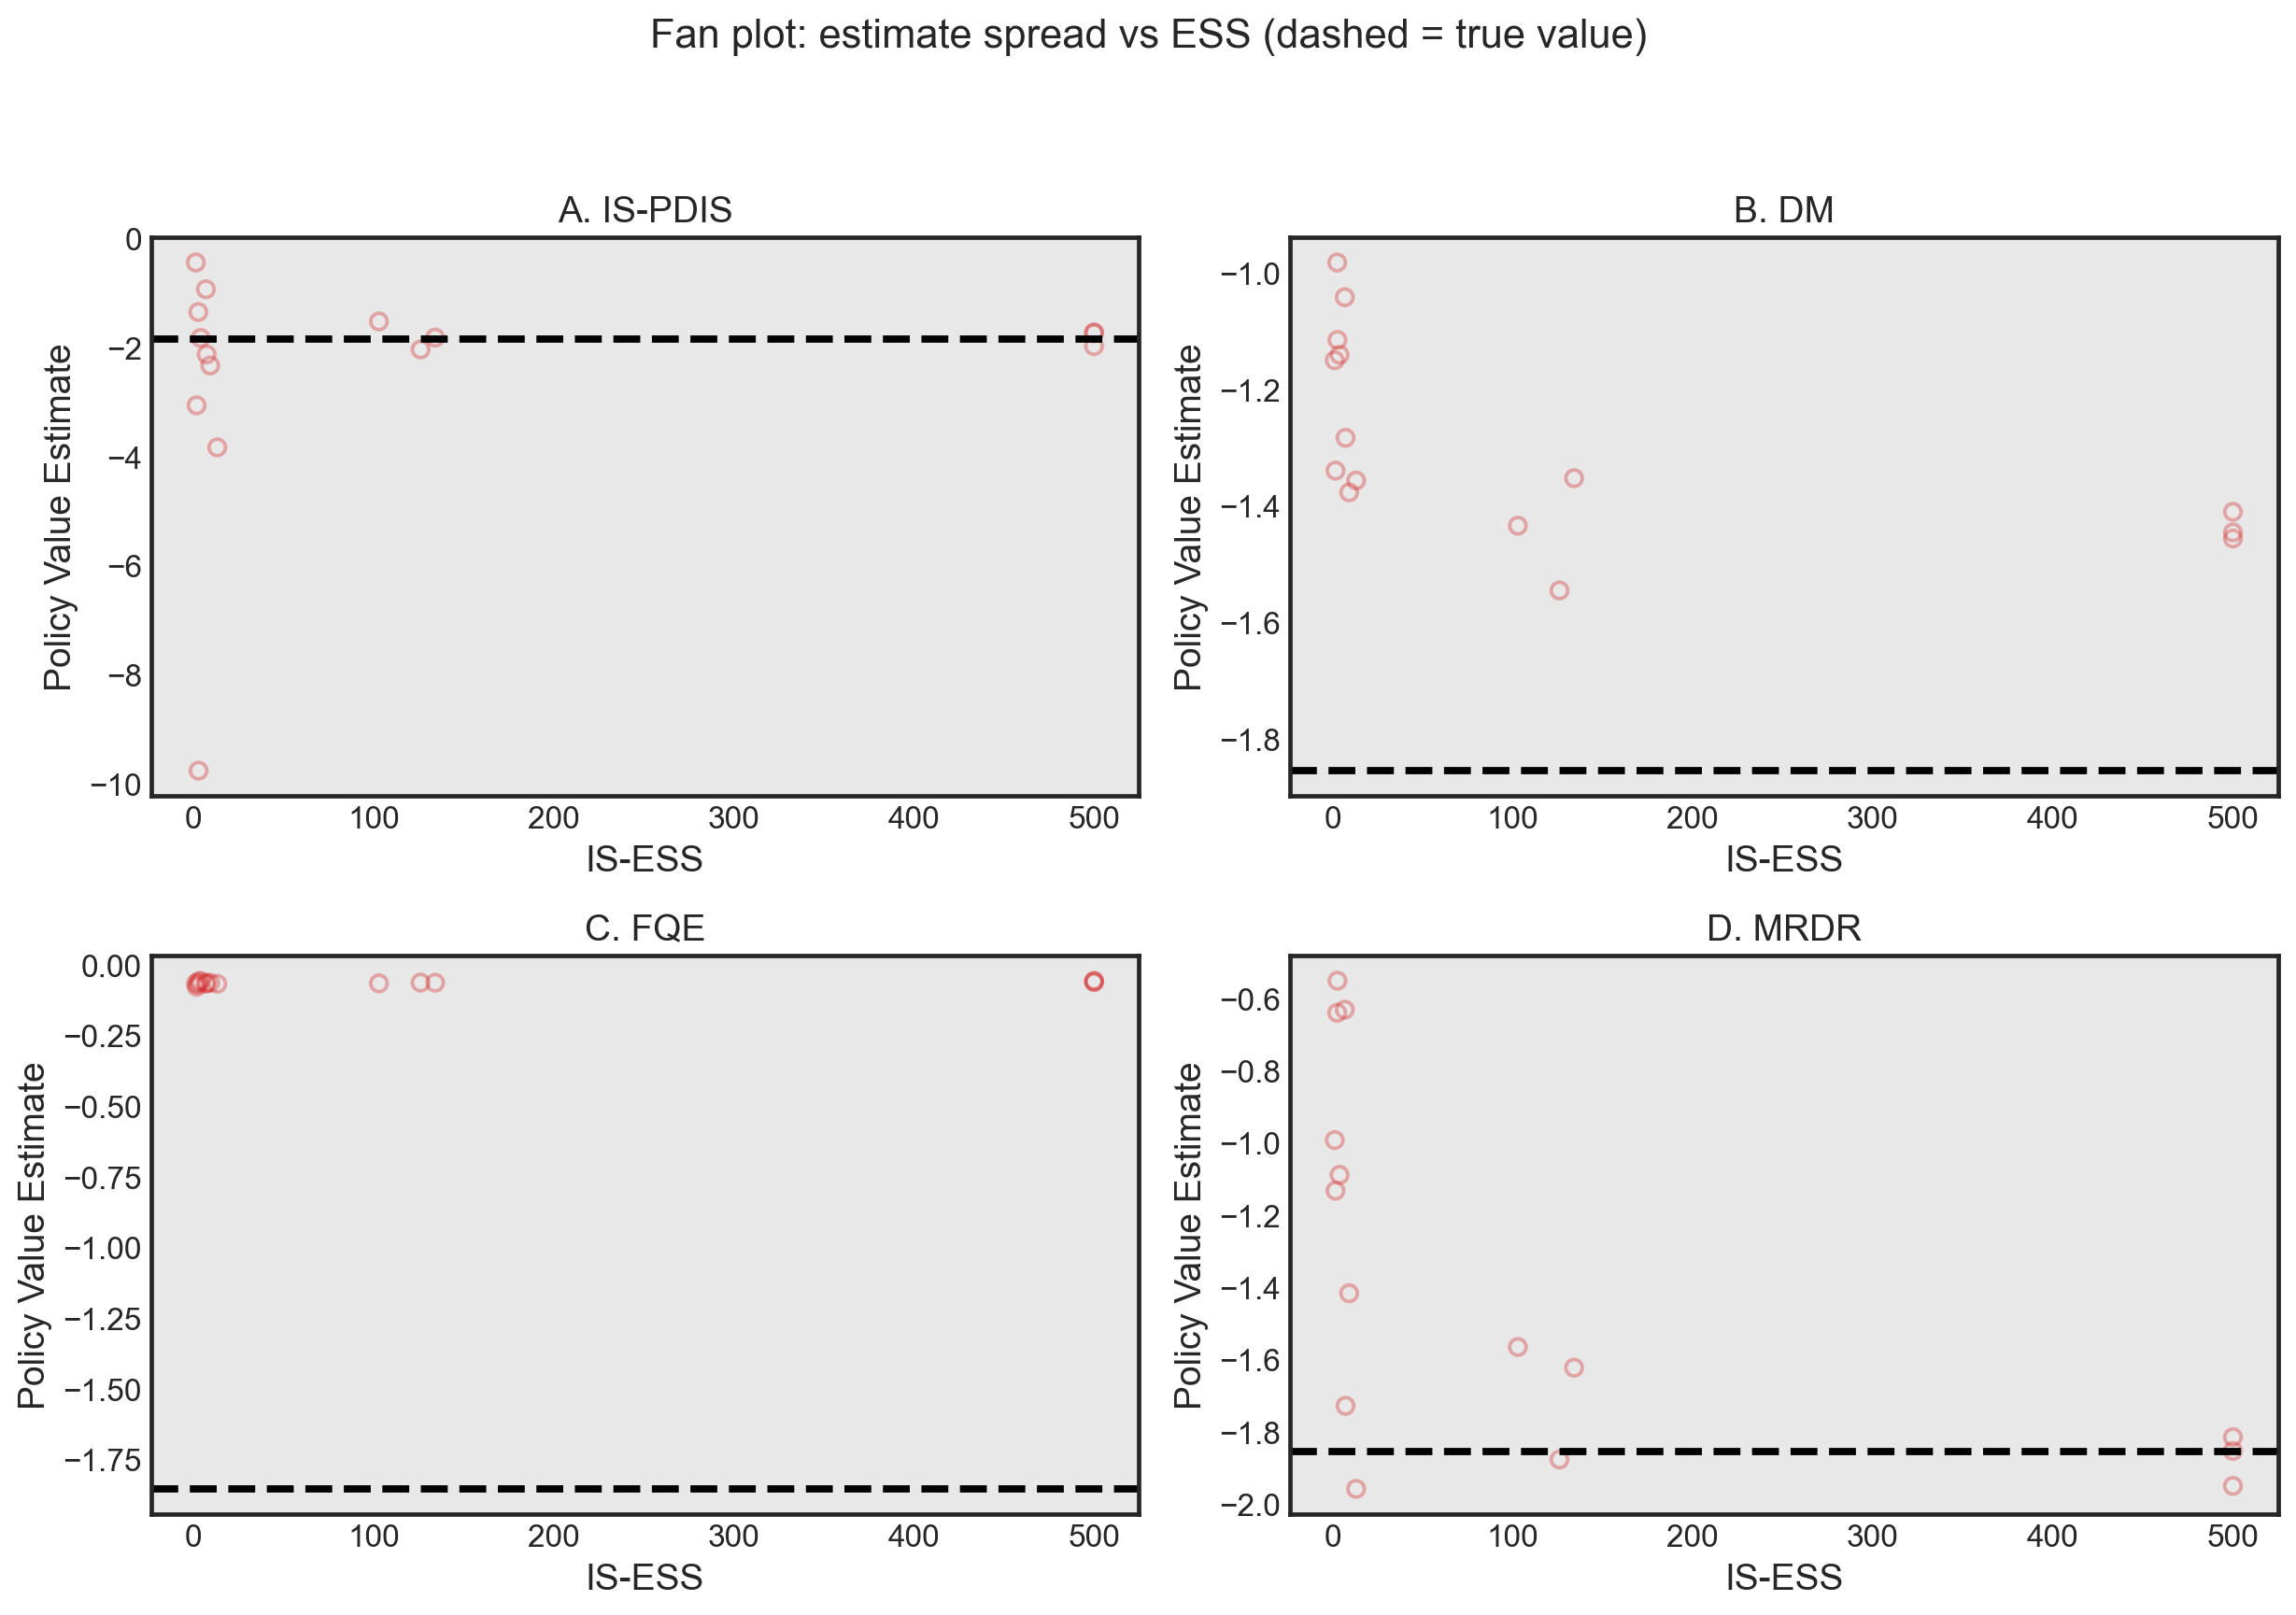

In [5]:
from IPython.display import Image, display

for name in [
    "benchmark_fig1_ess_vs_error_by_estimator.png",
    "benchmark_fig2_same_ess_different_error.png",
    "benchmark_fig3_ess_changes_error_stability.png",
    "benchmark_fig4_fan_estimate_vs_ess.png",
]:
    p = fig_dir / name
    if p.exists():
        print(name)
        display(Image(filename=str(p)))
